<a href="https://colab.research.google.com/github/ireneloreina-arch/PE/blob/main/Prueba1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio: simular y visualizar PAS

Objetivo final: completar un cuaderno como este para generar todas las imágenes del PAS de las diapositivas, subirlo a vuestro perfil de GitHub, y compartirlo conmigo. (Para final de la semana que viene, fecha a concretar).

Sobre el uso de IA generativa / LLMs:
* Se os anima a usarla para desatascaros en pasos pequeños y muy concretos (que te explique cómo hacer la media por filas de una matriz; que te explique cómo funciona cierta función que el profesor ha mencionado etc.).
* Pero no tiene sentido usarla para pasos excesivamente grandes en los que perdéis el control de qué se está haciendo (por ejemplo, decirle que te genere las figuras directamente).
* El verdadero objetivo final es entender el proceso, desarrollar habilidades de planificación, y asimilar las estructuras de pensamiento matemático-computacional subyacentes. Estáis en etapa formativa, no en etapa productiva.
* Como posible control, yo podré convocaros en clase o tutoría para que me expliquéis cómo funciona vuestro código.
* Pero, al fin y al cabo, lo que más está en juego es vuestra formación: adquirir valor añadido (ser capaz de desarrollar unas estructuras mentales que os permitan resolver problemas complejos en el futuro, problemas que quizás sean diferentes a los que hay hoy día), o ser una pieza de poco valor añadido y fácilmente sustituible (un “usuario de IA”).

Se recomienda que avancéis de aquí al lunes. Probablemente le dediquemos lunes y martes, y ya después pasemos a otra cosa. Y tendréis que entregarlo a final de semana (fecha a concretar).

Si escribís sobre este notebook que os comparto, vuestros cambios no se guardarán (porque solo tenéis permisos de lectura). Tendréis que crear una copia vuestra ("Archivo > Guardar una copia en Drive").

---------------------------------------------------------------

In [2]:
import numpy as np
from matplotlib import pyplot as plt

## El núcleo: implementar una función para simular el PAS

Define una función `simular_PAS` que reciba tres argumentos:
* p: este es el parámetro principal del PAS. Es la probabilidad de tomar el valor 1 en cada paso (y la probabilidad de tomar el -1 sería $1-p$). Es un valor entre 0 y 1.
* n: el número de pasos a simular para cada trayectoria. Un número natural.
* reps: el número de trayectorias a simular. Un número natural.

La función debe devolver un array de numpy con dimensionalidad `(reps, n)`, que contenga los valores del PAS en cada paso para cada trayectoria.  

Esqueleto de la función a construir (a completar por vosotros):

In [3]:
def simular_PAS(p, n, reps=1):
    # Simula múltiples trayectorias de un Paseo Aleatorio Simple (PAS)

    # Input:
    # p: probabilidad de que en cada paso el incremento sea +1 (0 ≤ p ≤ 1)
    # n: número de pasos de cada trayectoria (número de columnas)
    # reps: número de trayectorias independientes a simular (número de filas), por defecto 1

    # Output:
    # output: np.ndarray, shape (reps, n), donde cada fila representa
    # una trayectoria del PAS y cada columna el valor acumulado en ese paso

    # Paso 1: generar los incrementos aleatorios (+1 o -1)
    # Shape: (reps, n)
    # Creamos una matriz donde cada elemento es 1 con prob 'p' y -1 con prob '1-p'
    pasos = np.random.choice([1, -1], size=(reps, n), p=[p, 1-p])

    # Paso 2: calcular la suma acumulada a lo largo del tiempo (eje 1)
    # Esto convierte incrementos en posiciones del proceso
    # suma los elementos a lo largo de las columnas (el tiempo).
    # Si la trayectoria i en el paso j es la suma de los incrementos anteriores.
    # Shape: (reps, n)
    output = np.cumsum(pasos, axis=1)

    return output  # Shape: (reps, n)



Primero piensa durante un rato cómo lo harías, e intenta completar la función. Si te quedas atrancado/a, puedes mirar la pista de abajo. **Importante**: lo fundamental de la frase anterior es "*si te quedas atrancado/a*", es decir, debes pensarlo un rato por tu cuenta. De lo contrario, si vas directo a la solución, no se produce ningún aprendizaje y no te sirve de nada.

----------------------------------------

Pista:

En principio, uno podría pensar en incluir dos bucles for:
* uno para iterar sobre las diferentes trayectorias que queremos generar (`reps`),
* otro para iterar sobre los diferentes pasos dentro de cada trayectoria (`n`).

Puedes eliminar ambos bucles construyendo un array de numpy de shape `(reps, n)` que, en cada posición, contenga un $1$ con probabilidad $p$ (y $-1$ con probabilidad $1-p$). Para esto, piensa en usar `np.random.rand` o `np.random.choice`.

Y trabajar ahora con ese array usando herramientas de numpy (piensa qué necesitas hacer con ese array, y busca en internet/LLM herramientas de numpy que hagan eso).


## Visualización 1: diferentes trayectorias del PAS (sin media ni desviación típica teóricas)

Escribir código para crear las imágenes de las diapositivas 16 ($p=0.5$), 17 ($p=0.6$) y 18 ($p=0.4$) del tema 1.

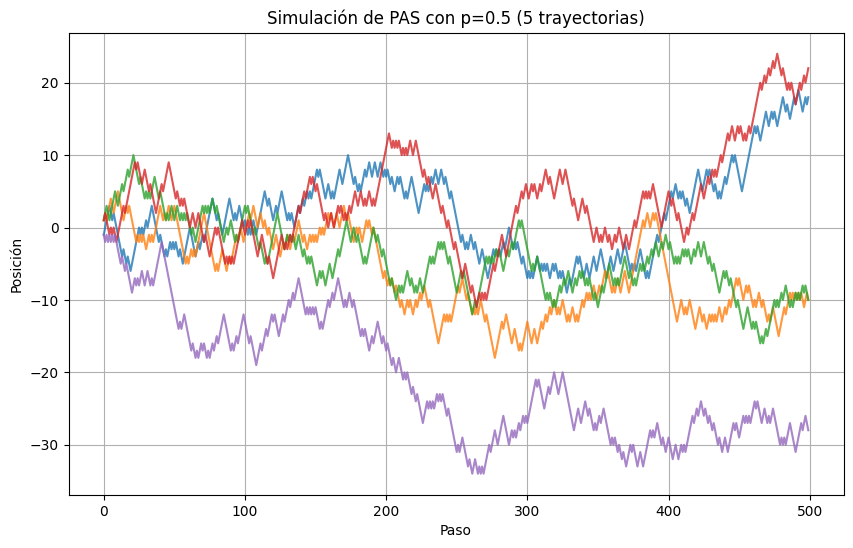

In [20]:
##Primer caso (diapositiva 16):

# Parámetros claros
n, reps, p = 500, 5, 0.5
  #con:
  #n: número de pasos en el tiempo T={1,....,500} que dará a trayectoria
  #reps: cantidad de simulaciones independientes
  #p:probabilida de que el incremento en cada paso sea +1

# Generamos datos
trayectorias = simular_PAS(p, n, reps)
  #Llamamos a la función que hemos definido antes
  #Esta función genrea una matriz de datos donde cada fila
  #o columna representa el comino recorrido por una trayectoria

plt.figure(figsize=(10, 6)) #Tamaño que va a tomar la figura

# Usamos la transposición (.T) para evitar el bucle for para dibujar cada trayectoria una por una,
#asi hacemos que el programa lo interprete como que cada columna como una serie de datos,
#dibujando así las trayectorias de forma simultanea
# No hace falta definir 'x' con linspace, plt lo hace solo si empiezas en 0
plt.plot(trayectorias.T, alpha=0.8)
  #el alpha=0.8 le da un poco de transparencia a las lineas para que, si se cruzan se sigan viendo bien

#f-string para evitar errores entre el código y el texto
plt.title(f"Simulación de PAS con p=0.5 (5 trayectorias)")
plt.xlabel("Paso")
plt.ylabel("Posición")
plt.grid(True) #Añade cuadrícula en el fondo

plt.show()

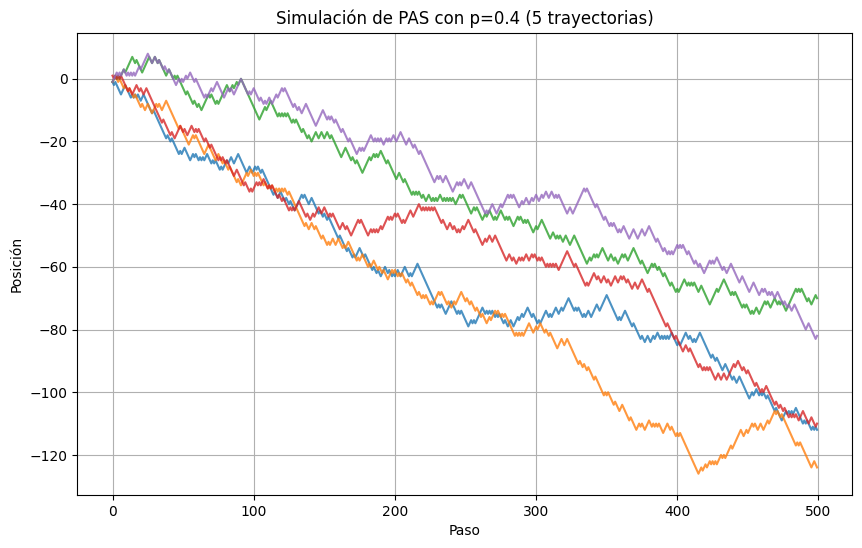

In [21]:
#Segundo caso (diapositiva 17):

# Parámetros claros
n, reps, p = 500, 5, 0.4

# Generamos datos
trayectorias = simular_PAS(p, n, reps)

plt.figure(figsize=(10, 6))

# Usamos la transposición (.T) para evitar el bucle for (más eficiente)
# No hace falta definir 'x' con linspace, plt lo hace solo si empiezas en 0
plt.plot(trayectorias.T, alpha=0.8)

# Título dinámico (f-string) para evitar errores entre el código y el texto
plt.title(f"Simulación de PAS con p=0.4 (5 trayectorias)")
plt.xlabel("Paso")
plt.ylabel("Posición")
plt.grid(True)

plt.show()

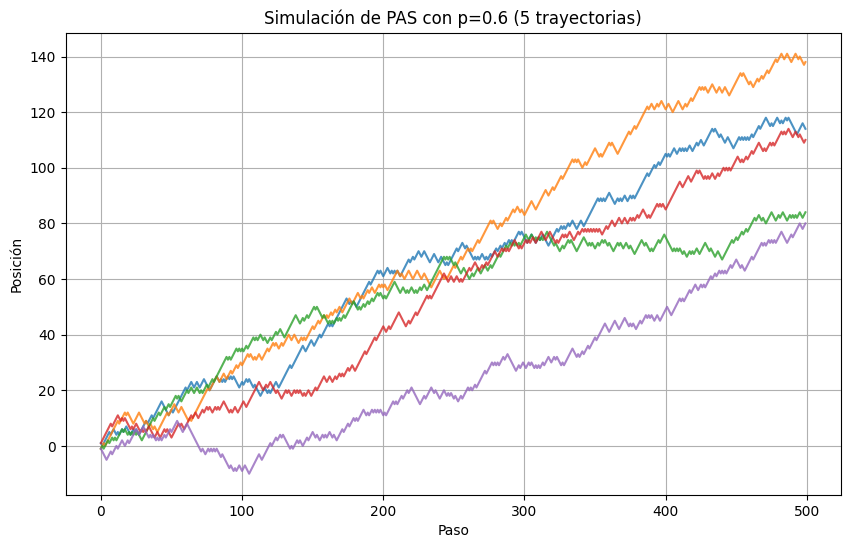

In [19]:
##Tercer caso (diapositiva 18):

# Parámetros claros
n, reps, p = 500, 5, 0.6

# Generamos datos
trayectorias = simular_PAS(p, n, reps)

plt.figure(figsize=(10, 6))

# Usamos la transposición (.T) para evitar el bucle for (más eficiente)
# No hace falta definir 'x' con linspace, plt lo hace solo si empiezas en 0
plt.plot(trayectorias.T, alpha=0.8)

# Título dinámico (f-string) para evitar errores entre el código y el texto
plt.title(f"Simulación de PAS con p=0.6 (5 trayectorias)")
plt.xlabel("Paso")
plt.ylabel("Posición")
plt.grid(True)

plt.show()

## Visualización 2: diferentes trayectorias del PAS (con media y desviación típica teóricas)

Escribir código para crear las imágenes de las diapositivas 30 ($p=0.5$), 31 ($p=0.75$), 32 ($p=0.95$) del tema 1.

Para el sombreado de las imágenes, que tiene amplitud $\pm$ 1 o 2 veces la desviación típica, busca en internet/LLM qué función de matplotlib te permite hacerlo.

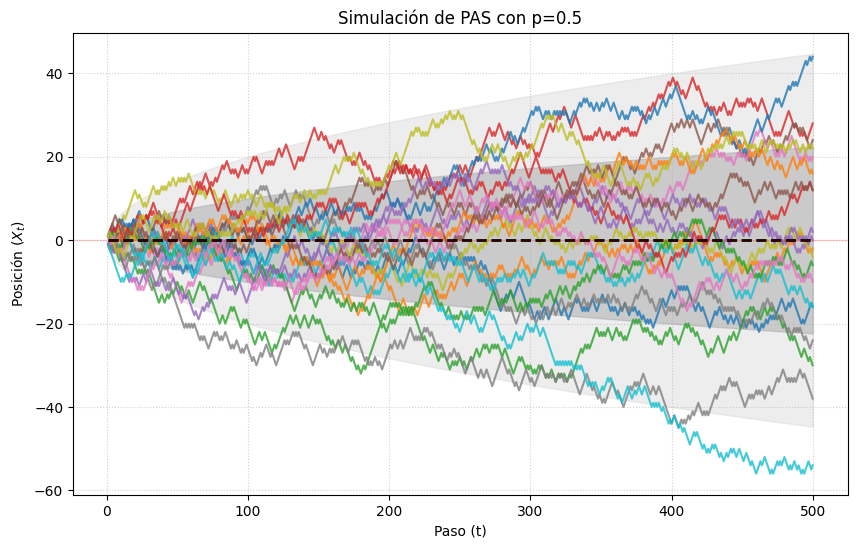

In [28]:
# Primer caso (diapositiva 30)
n, reps, p = 500, 20, 0.5

# 2. Generamos las trayectorias
trayectorias = simular_PAS(p, n, reps)#Obtenemos una matriz de dimensiones 20x500
                                      #donde cada fila es una realización del proceso
t = np.arange(1, n + 1) #Crea un vector que representa el eje temporal(los pasos del proceso)

# 3. Cálculos Teóricos para el PAS
media_teorica = t * (2 * p - 1)
  #Calculamos la media teórica con la expresión que se encuentra en las diapositivas

# Desviación típica: sqrt(n * 4 * p * (1 - p))
std_teorica = np.sqrt(t * 4 * p * (1 - p))
  # La varianza de cada paso es 4p(1-p) luego la varianza en un instante t será:
  # t4p(1-p) y su raiz cuadrada es la desviación típica

# 4. Crear la gráfica
plt.figure(figsize=(10, 6))

# Sombreado de las bandas (±1 y ±2 desviaciones típicas)
# plt.fill_between crea bandas de color que representan la dispersión esperada del proceso
plt.fill_between(t, media_teorica - 2 * std_teorica, media_teorica + 2 * std_teorica,
                 color='lightgray', alpha=0.4, label=r'$\pm 2\sigma$ teórica')

plt.fill_between(t, media_teorica - std_teorica, media_teorica + std_teorica,
                 color='darkgray', alpha=0.5, label=r'$\pm 1\sigma$ teórica')

# Dibujamos las 5 trayectorias usando la transposición .T
plt.plot(t, trayectorias.T, alpha=0.8, lw=1.5)

# Dibujamos la media teórica (línea negra discontinua)
plt.plot(t, media_teorica, color='black', linestyle='--', linewidth=2, label='Media teórica')
  #Dibuja una línea horizontal que muestra el comportamiento esperado del proceso

# 5. Estética y anotaciones
plt.title(f"Simulación de PAS con p=0.5")
plt.xlabel("Paso (t)")
plt.ylabel("Posición ($X_t$)")
plt.grid(True)


plt.show() #Muestra el gráfico resultante

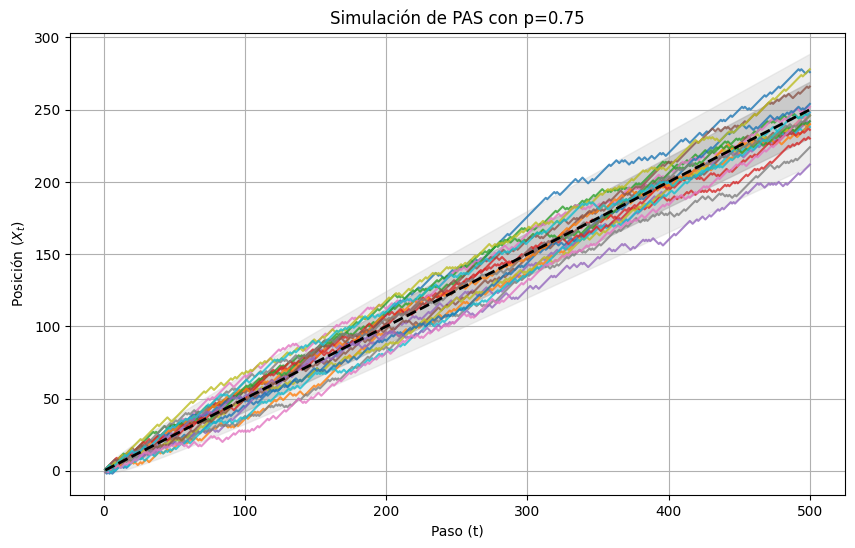

In [29]:
# Segundo caso (diapositiva 31)
n, reps, p = 500, 20, 0.75

# 2. Generamos las trayectorias
trayectorias = simular_PAS(p, n, reps)
t = np.arange(1, n + 1) # Eje de tiempo para los cálculos teóricos

# 3. Cálculos Teóricos para el PAS
media_teorica = t * (2 * p - 1)
# Desviación típica: sqrt(n * 4 * p * (1 - p))
std_teorica = np.sqrt(t * 4 * p * (1 - p))

# 4. Crear la gráfica
plt.figure(figsize=(10, 6))

# Sombreado de las bandas (±1 y ±2 desviaciones típicas)
plt.fill_between(t, media_teorica - 2 * std_teorica, media_teorica + 2 * std_teorica,
                 color='lightgray', alpha=0.4, label=r'$\pm 2\sigma$ teórica')

plt.fill_between(t, media_teorica - std_teorica, media_teorica + std_teorica,
                 color='darkgray', alpha=0.5, label=r'$\pm 1\sigma$ teórica')

# Dibujamos las 5 trayectorias usando la transposición .T
plt.plot(t, trayectorias.T, alpha=0.8, lw=1.5)

# Dibujamos la media teórica (línea negra discontinua)
plt.plot(t, media_teorica, color='black', linestyle='--', linewidth=2, label='Media teórica')

# 5. Estética y anotaciones
plt.title(f"Simulación de PAS con p=0.75")
plt.xlabel("Paso (t)")
plt.ylabel("Posición ($X_t$)")
plt.grid(True)


plt.show()

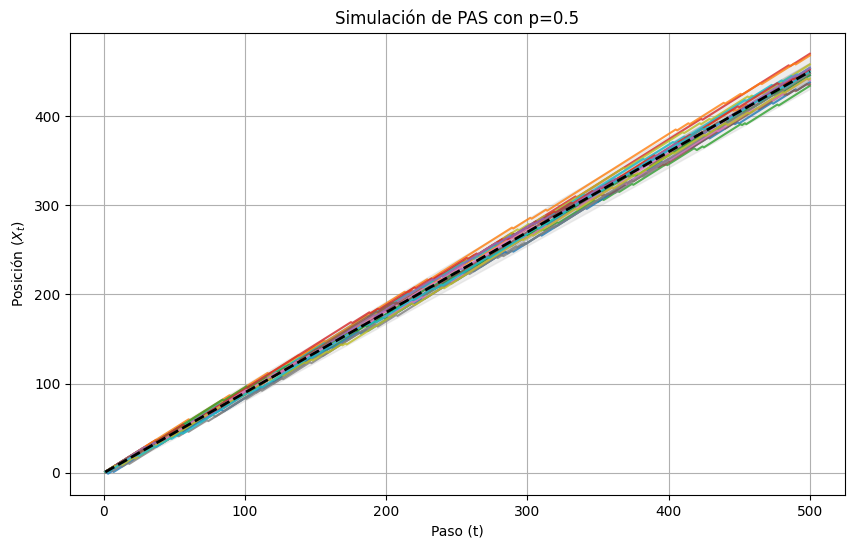

In [30]:
#Tercer caso (diapositiva 32)
n, reps, p = 500, 20, 0.95

# 2. Generamos las trayectorias
trayectorias = simular_PAS(p, n, reps)
t = np.arange(1, n + 1) # Eje de tiempo para los cálculos teóricos

# 3. Cálculos Teóricos para el PAS
media_teorica = t * (2 * p - 1)
# Desviación típica: sqrt(n * 4 * p * (1 - p))
std_teorica = np.sqrt(t * 4 * p * (1 - p))

# 4. Crear la gráfica
plt.figure(figsize=(10, 6))

# Sombreado de las bandas (±1 y ±2 desviaciones típicas)
plt.fill_between(t, media_teorica - 2 * std_teorica, media_teorica + 2 * std_teorica,
                 color='lightgray', alpha=0.4, label=r'$\pm 2\sigma$ teórica')

plt.fill_between(t, media_teorica - std_teorica, media_teorica + std_teorica,
                 color='darkgray', alpha=0.5, label=r'$\pm 1\sigma$ teórica')

# Dibujamos las 5 trayectorias usando la transposición .T
plt.plot(t, trayectorias.T, alpha=0.8, lw=1.5)

# Dibujamos la media teórica (línea negra discontinua)
plt.plot(t, media_teorica, color='black', linestyle='--', linewidth=2, label='Media teórica')

# 5. Estética y anotaciones
plt.title(f"Simulación de PAS con p=0.5")
plt.xlabel("Paso (t)")
plt.ylabel("Posición ($X_t$)")
plt.grid(True)


plt.show()

## Visualización 3: visualización de la media empírica del PAS cuando aumentamos el número de trayectorias (junto con la media teórica)

Escribir código para crear la imagen de la diapositiva 35.

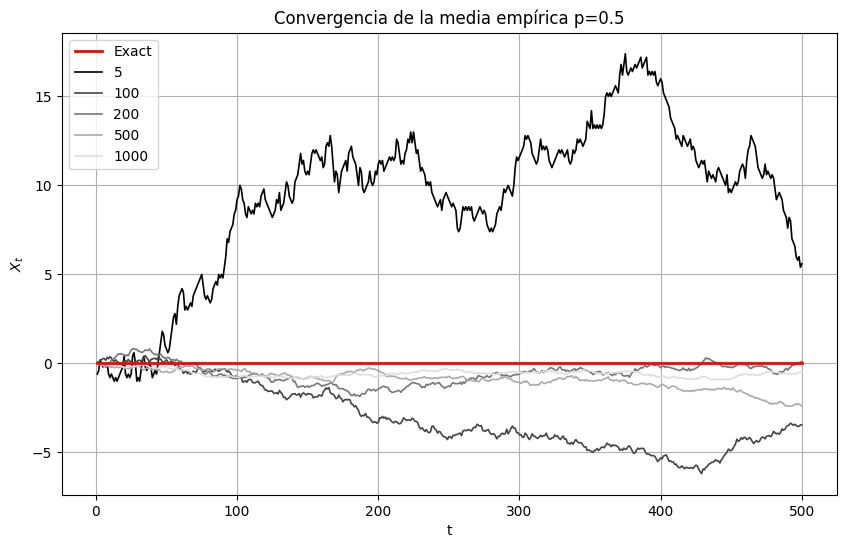

In [33]:
# Gráfica de la diapositiva 35

# 1. Configuración de parámetros
p = 0.5
n = 500
lista_reps = [5, 100, 200, 500, 1000] # Diferentes cantidades de trayectorias.
  #Queremos ver que pasa si promediamos solo 5 trayectorias frente a promediar 1000
colores = ['black', '#444444', '#777777', '#AAAAAA', '#DDDDDD']
  # Escala de grises, para que cada línea de la gráfica tenga un color distinto

# 2. Preparar el eje de tiempo y la media teórica
t = np.arange(1, n + 1)
media_teorica = t * (2 * p - 1)

# 3. Crear la gráfica
plt.figure(figsize=(10, 6))

# Dibujamos la media teórica primero (Línea roja)
plt.plot(t, media_teorica, color='red', label='Exact', lw=2, zorder=10)
  #zorder=10 asegura que la línea roja se dibuje por encima de las demás
  #lw: grosor de la línea

# 4. Simular y calcular la media empírica para cada reps
for reps, color in zip(lista_reps, colores): # Itera simultaneamente sobre las lista de repeteciones y la de colores
    # Generamos las trayectorias
    trayectorias = simular_PAS(p, n, reps) # Crea matriz de tamaño repsxn

    media_empirica = np.mean(trayectorias, axis=0)
      # Calcula el promedio de las reps trayectorias para cada instante de tiempo t
      # axis=0 calcula la media verticalmente, es decir, se sitúa en la primera columna (el paso t=1) y calcula el promedio
      # de todos los valores que hay en esa columna (todas las simulaciones para ese instante)
      #como resueltado obtenemos un único vector con longitud igual al número de pasos

    plt.plot(t, media_empirica, color=color, label=f'{reps}', lw=1.2)
      # Dibuja la media calculada para ese grupo de repeticiones

# 5. Estética de la gráfica (idéntica a tu captura)
plt.title(f'Convergencia de la media empírica p=0.5')
plt.xlabel('t')
plt.ylabel('$X_t$')
plt.grid(True)
plt.legend()

plt.show()